# Vortex-AI Dynamic Graph Regime & Risk Notebook

This notebook downloads NIFTY-50 prices, preprocesses them into 60-day return windows
with crisis-regime labels, builds empirical (Pearson + Granger) adjacency graphs, trains a
Dynamic Graph Attention Network (GAT) for regime classification, and produces an EDA
dashboard. It runs on Kaggle (`/kaggle/working`) or a local checkout (`data/raw`).

In [35]:
# Vortex-AI notebook setup.
%pip install -q yfinance
from pathlib import Path


def resolve_raw_data_dir() -> Path:
    kaggle_root = Path("/kaggle/working")
    if kaggle_root.exists():
        data_dir = kaggle_root / "data" / "raw"
    else:
        notebook_dir = Path.cwd()
        candidates = [notebook_dir / "data" / "raw", *[parent / "data" / "raw" for parent in notebook_dir.parents]]
        data_dir = next((candidate for candidate in candidates if candidate.parent.exists()), candidates[0])
    data_dir.mkdir(parents=True, exist_ok=True)
    return data_dir


RAW_DATA_DIR = resolve_raw_data_dir()
print(f"Raw data directory: {RAW_DATA_DIR}")

Note: you may need to restart the kernel to use updated packages.
Raw data directory: \kaggle\working\data\raw



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import numpy as np
import pandas as pd
import yfinance as yf

NIFTY50 = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "HINDUNILVR.NS",
    "ICICIBANK.NS", "KOTAKBANK.NS", "BHARTIARTL.NS", "ITC.NS", "AXISBANK.NS",
    "SBIN.NS", "LT.NS", "BAJFINANCE.NS", "HCLTECH.NS", "ASIANPAINT.NS",
    "MARUTI.NS", "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS", "NESTLEIND.NS",
    "WIPRO.NS", "POWERGRID.NS", "NTPC.NS", "M&M.NS", "TECHM.NS",
    "TATAMOTORS.NS", "TATASTEEL.NS", "JSWSTEEL.NS", "BAJAJ-AUTO.NS", "CIPLA.NS",
    "DRREDDY.NS", "DIVISLAB.NS", "HEROMOTOCO.NS", "ONGC.NS", "COALINDIA.NS",
    "BPCL.NS", "GRASIM.NS", "ADANIPORTS.NS", "EICHERMOT.NS", "APOLLOHOSP.NS",
    "HINDALCO.NS", "TATACONSUM.NS", "BRITANNIA.NS", "SHREECEM.NS", "UPL.NS",
    "BAJAJFINSV.NS", "SBILIFE.NS", "HDFCLIFE.NS", "INDUSINDBK.NS", "LTIM.NS",
]

print("Downloading NIFTY 50 historical data...")
prices = yf.download(NIFTY50, start="2010-01-01", end="2024-12-31", auto_adjust=True, threads=True, progress=False)
if prices.empty or "Close" not in prices or "Volume" not in prices:
    raise RuntimeError("Yahoo Finance returned no usable Close/Volume data")
close = prices["Close"].apply(pd.to_numeric, errors="coerce")
volume = prices["Volume"].apply(pd.to_numeric, errors="coerce")
close = close.ffill().bfill()
volume = volume.ffill().bfill()
valid_columns = close.columns[close.notna().all() & volume.notna().all()]
close, volume = close[valid_columns], volume[valid_columns]
if close.empty or len(close.columns) < 2:
    raise RuntimeError("Fewer than two complete assets were downloaded")
close.to_csv(RAW_DATA_DIR / "nifty50_close.csv")
volume.to_csv(RAW_DATA_DIR / "nifty50_volume.csv")
print(f"Download complete: {close.shape[0]} trading days x {close.shape[1]} stocks.")

$LTIM.NS: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found

2 Failed downloads:
['LTIM.NS', 'TATAMOTORS.NS']: possibly delisted; no timezone found


Download complete: 3700 trading days x 48 stocks.


In [37]:
import numpy as np
import pandas as pd


def compute_log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    close_df = close_df.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    close_df = close_df.dropna(axis=1, how="all").ffill().bfill()
    if close_df.empty or (close_df <= 0).any().any() or close_df.isna().any().any():
        raise ValueError("Close prices must be positive, finite, and non-empty")
    returns = np.log(close_df / close_df.shift(1))
    return returns.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def label_regimes(returns_df: pd.DataFrame, vol_window: int = 20, crisis_pct: float = 85.0) -> pd.Series:
    if returns_df.empty or vol_window < 1 or not 0 < crisis_pct < 100:
        raise ValueError("Invalid returns data, volatility window, or crisis percentile")
    realized_vol = returns_df.std(axis=1).rolling(vol_window, min_periods=1).mean()
    rolling_5d = returns_df.rolling(5, min_periods=1).sum()
    drawdown_frac = (rolling_5d < -0.05).mean(axis=1)
    circuit_prox = (returns_df.abs() > 0.095).mean(axis=1)
    vol_q99 = realized_vol.quantile(0.99)
    vol_norm = realized_vol / vol_q99 if pd.notna(vol_q99) and vol_q99 > 0 else realized_vol
    crisis_score = (0.5 * vol_norm + 0.3 * drawdown_frac + 0.2 * circuit_prox).fillna(0.0)
    threshold = np.percentile(crisis_score, crisis_pct)
    return (crisis_score >= threshold).astype(int)


def make_windows(returns_df: pd.DataFrame, labels: pd.Series, T: int = 60):
    if T < 1 or len(returns_df) <= T or len(returns_df) != len(labels):
        raise ValueError("Need matching returns and labels with more rows than T")
    arr, lab = returns_df.to_numpy(dtype=np.float32), labels.to_numpy(dtype=np.int64)
    windows = np.stack([arr[i - T : i] for i in range(T, len(arr))])
    window_labels = lab[T - 1 : -1]
    return windows, window_labels


close_path = RAW_DATA_DIR / "nifty50_close.csv"
if not close_path.exists():
    raise FileNotFoundError(f"Missing {close_path}. Run the download cell first!")
close_df = pd.read_csv(close_path, index_col=0, parse_dates=True)
returns_df = compute_log_returns(close_df)
labels = label_regimes(returns_df, vol_window=20, crisis_pct=85.0)
windows, window_labels = make_windows(returns_df, labels, T=60)

np.save(RAW_DATA_DIR / "returns.npy", returns_df.to_numpy(dtype=np.float32))
np.save(RAW_DATA_DIR / "regimes.npy", labels.to_numpy(dtype=np.int64))
np.save(RAW_DATA_DIR / "windows.npy", windows)
np.save(RAW_DATA_DIR / "window_regimes.npy", window_labels)

print(f"Preprocessed: {returns_df.shape[0]} Days | Crisis Days: {labels.sum()} ({labels.mean():.1%})")
print(f"Created 60-Day Windows Tensor: {windows.shape}")

Preprocessed: 3700 Days | Crisis Days: 555 (15.0%)
Created 60-Day Windows Tensor: (3640, 60, 48)


In [38]:
from pathlib import Path
import time
import numpy as np
import torch
from scipy.stats import f as f_distribution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Building empirical graphs on device: {device}")

def build_empirical_graphs(
    returns_tensor: torch.Tensor,
    window_size: int = 60,
    granger_lag: int = 2,
    pearson_threshold: float = 0.3,
    granger_alpha: float = 0.5,
    batch_size: int = 256,
):
    if returns_tensor.ndim != 2:
        raise ValueError("returns_tensor must have shape [days, assets]")
    if window_size <= granger_lag or granger_lag < 2:
        raise ValueError("window_size must be greater than granger_lag >= 2")
    if not 0.0 <= granger_alpha <= 1.0:
        raise ValueError("granger_alpha must be between 0 and 1")
    if batch_size < 1:
        raise ValueError("batch_size must be positive")

    num_days, num_assets = returns_tensor.shape
    num_windows = num_days - window_size
    if num_windows < 1 or num_assets < 1:
        raise ValueError("Need at least one complete window and one asset")
    windows = returns_tensor.unfold(0, window_size, 1).permute(0, 2, 1)[:num_windows].to(device)
    windows = torch.nan_to_num(windows, nan=0.0, posinf=0.0, neginf=0.0)

    centered = windows - windows.mean(dim=1, keepdim=True)
    covariance = torch.bmm(centered.transpose(1, 2), centered) / max(window_size - 1, 1)
    std = torch.sqrt(torch.diagonal(covariance, dim1=1, dim2=2).clamp(min=1e-8)).unsqueeze(-1)
    correlation = torch.nan_to_num(covariance / (std @ std.transpose(1, 2)), nan=0.0, posinf=0.0, neginf=0.0)
    pearson_adj = torch.where(correlation.abs() >= pearson_threshold, correlation.abs(), torch.zeros_like(correlation))
    eye_mask = torch.eye(num_assets, device=device, dtype=torch.bool)
    pearson_adj[:, eye_mask] = 0.0

    m_obs = window_size - granger_lag
    df_num = float(granger_lag)
    df_den = float(m_obs - (2 * granger_lag + 1))
    if df_den <= 0:
        raise ValueError("window_size is too small for the requested Granger lag")

    targets = windows[:, granger_lag:, :].transpose(1, 2).unsqueeze(-1)
    ones = torch.ones((num_windows, num_assets, m_obs, 1), device=device)
    lag_1 = windows[:, granger_lag - 1 : window_size - 1, :].transpose(1, 2).unsqueeze(-1)
    lag_2 = windows[:, granger_lag - 2 : window_size - 2, :].transpose(1, 2).unsqueeze(-1)
    restricted_design = torch.cat([ones, lag_1, lag_2], dim=-1)
    a_restricted = restricted_design.transpose(-2, -1) @ restricted_design + 1e-6 * torch.eye(3, device=device)
    b_restricted = restricted_design.transpose(-2, -1) @ targets
    coef_restricted = torch.linalg.pinv(a_restricted) @ b_restricted
    target_energy = (targets ** 2).sum(dim=-2)
    rss_restricted = (target_energy - (b_restricted.transpose(-2, -1) @ coef_restricted).squeeze(-1)).clamp_min(1e-8)

    granger_batches = []
    for start in range(0, num_windows, batch_size):
        end = min(start + batch_size, num_windows)
        b_w = end - start
        batch_targets = targets[start:end]
        batch_design = restricted_design[start:end].unsqueeze(2).expand(b_w, num_assets, num_assets, m_obs, 3)
        pred_lag_1 = windows[start:end, granger_lag - 1 : window_size - 1, :].transpose(1, 2).unsqueeze(1).unsqueeze(-1)
        pred_lag_2 = windows[start:end, granger_lag - 2 : window_size - 2, :].transpose(1, 2).unsqueeze(1).unsqueeze(-1)
        predictor_lags = torch.cat([pred_lag_1, pred_lag_2], dim=-1).expand(b_w, num_assets, num_assets, m_obs, 2)
        unrestricted_design = torch.cat([batch_design, predictor_lags], dim=-1)

        a_unrestricted = unrestricted_design.transpose(-2, -1) @ unrestricted_design + 1e-6 * torch.eye(5, device=device)
        b_unrestricted = unrestricted_design.transpose(-2, -1) @ batch_targets.unsqueeze(2)
        coef_unrestricted = torch.linalg.pinv(a_unrestricted) @ b_unrestricted
        batch_energy = target_energy[start:end].unsqueeze(2).unsqueeze(-1)
        rss_unrestricted = (batch_energy - b_unrestricted.transpose(-2, -1) @ coef_unrestricted).squeeze(-1).squeeze(-1).clamp_min(1e-8)

        batch_rss_restricted = rss_restricted[start:end].expand(b_w, num_assets, num_assets)
        f_statistic = ((batch_rss_restricted - rss_unrestricted) / df_num) / (rss_unrestricted / df_den)
        f_statistic = torch.nan_to_num(f_statistic, nan=0.0, posinf=0.0, neginf=0.0).clamp_min(0.0)
        p_values = torch.from_numpy(f_distribution.sf(f_statistic.cpu().numpy(), df_num, df_den)).to(device).float()
        batch_granger = torch.where(p_values < 0.05, 1.0 - p_values, torch.zeros_like(p_values))
        batch_granger[:, eye_mask] = 0.0
        granger_batches.append(batch_granger)

    granger_adj = torch.cat(granger_batches, dim=0)
    return torch.nan_to_num(granger_alpha * pearson_adj + (1.0 - granger_alpha) * granger_adj)

start_time = time.time()
returns_path = RAW_DATA_DIR / "returns.npy"
if not returns_path.exists():
    raise FileNotFoundError(f"Missing {returns_path}. Run the preprocessing cell first!")
returns_tensor = torch.from_numpy(np.load(returns_path)).float()
adjacency_matrices = build_empirical_graphs(returns_tensor, window_size=60, granger_alpha=0.5, batch_size=256)
output_path = RAW_DATA_DIR / "adj_matrices.npy"
np.save(output_path, adjacency_matrices.cpu().numpy())
elapsed = time.time() - start_time
print(f"Finished in {elapsed:.2f} seconds!")
print(f"Saved adjacency tensor to {output_path}: {adjacency_matrices.shape}")

Building empirical graphs on device: cuda
Finished in 30.22 seconds!
Saved adjacency tensor to \kaggle\working\data\raw\adj_matrices.npy: torch.Size([3640, 48, 48])


In [39]:
FILES = [
    "returns.npy",
    "regimes.npy",
    "windows.npy",
    "window_regimes.npy",
    "adj_matrices.npy",
]

print("DATA VERIFICATION")
for fname in FILES:
    path = RAW_DATA_DIR / fname
    if path.exists():
        arr = np.load(path)
        print(f"{fname:<20} | Shape: {str(arr.shape):<18} | Type: {arr.dtype}")
    else:
        print(f"Missing: {fname}")

DATA VERIFICATION
returns.npy          | Shape: (3700, 48)         | Type: float32
regimes.npy          | Shape: (3700,)            | Type: int64
windows.npy          | Shape: (3640, 60, 48)     | Type: float32
window_regimes.npy   | Shape: (3640,)            | Type: int64
adj_matrices.npy     | Shape: (3640, 48, 48)     | Type: float32


In [40]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_count = torch.cuda.device_count()
use_amp = device.type == "cuda"
print(f"Training on device: {device} | GPUs: {gpu_count} | Mixed precision: {use_amp}")

class VortexGraphDataset(Dataset):
    def __init__(self, data_dir: Path):
        windows = np.load(data_dir / "windows.npy")
        adjacency = np.load(data_dir / "adj_matrices.npy")
        labels = np.load(data_dir / "window_regimes.npy")
        if windows.ndim != 3 or adjacency.ndim != 3 or labels.ndim != 1:
            raise ValueError("Expected windows [W,T,N], adjacency [W,N,N], and labels [W]")
        if adjacency.shape[1] != adjacency.shape[2] or windows.shape[2] != adjacency.shape[1]:
            raise ValueError("Window asset count must match adjacency dimensions")
        num_samples = min(len(windows), len(adjacency), len(labels))
        if num_samples == 0:
            raise ValueError("Dataset is empty")
        windows, adjacency, labels = windows[:num_samples], adjacency[:num_samples], labels[:num_samples]
        if not np.isfinite(windows).all() or not np.isfinite(adjacency).all():
            raise ValueError("Dataset contains non-finite values")
        self.node_features = torch.from_numpy(windows).permute(0, 2, 1).float()
        self.adjacency = torch.from_numpy(adjacency).float()
        self.labels = torch.from_numpy(labels).long()
        print(f"Dataset: {len(self.labels)} samples | Nodes: {self.node_features.shape[1]} | Lookback T: {self.node_features.shape[2]}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.node_features[idx], self.adjacency[idx], self.labels[idx]

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int, dropout: float = 0.2):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.attention = nn.Linear(2 * out_features, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        batch_size, num_nodes, _ = x.shape
        projected = self.linear(x)
        source = projected.unsqueeze(2).expand(batch_size, num_nodes, num_nodes, -1)
        target = projected.unsqueeze(1).expand(batch_size, num_nodes, num_nodes, -1)
        scores = self.leaky_relu(self.attention(torch.cat([source, target], dim=-1))).squeeze(-1)
        # Self-loops prevent an all-masked softmax when a sparse graph has isolated nodes.
        adjacency = adjacency + torch.eye(num_nodes, device=adjacency.device).unsqueeze(0)
        masked_scores = scores.masked_fill(adjacency <= 0, torch.finfo(scores.dtype).min)
        attention_weights = self.dropout(F.softmax(masked_scores, dim=-1))
        return F.elu(attention_weights @ projected)

class DynamicGATEncoder(nn.Module):
    def __init__(self, in_dim: int = 60, hidden_dim: int = 64, out_dim: int = 32, num_classes: int = 2):
        super().__init__()
        self.gat1 = GraphAttentionLayer(in_dim, hidden_dim)
        self.gat2 = GraphAttentionLayer(hidden_dim, out_dim)
        self.classifier = nn.Sequential(
            nn.Linear(out_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        hidden = self.gat2(self.gat1(x, adjacency), adjacency)
        graph_embedding = torch.cat([hidden.mean(dim=1), hidden.max(dim=1).values], dim=-1)
        return self.classifier(graph_embedding)

full_dataset = VortexGraphDataset(RAW_DATA_DIR)
num_samples = len(full_dataset)
train_size = max(1, min(num_samples - 1, int(0.8 * num_samples)))
train_dataset = Subset(full_dataset, range(0, train_size))
val_dataset = Subset(full_dataset, range(train_size, num_samples))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=use_amp, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=use_amp, num_workers=0)

model = DynamicGATEncoder(in_dim=full_dataset.node_features.shape[2], hidden_dim=64, out_dim=32, num_classes=2)
if gpu_count > 1:
    model = nn.DataParallel(model)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=use_amp)
epochs = 20
print("Starting Dynamic GAT training...")

def run_epoch(model, loader, training: bool):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for features_b, adjacency_b, labels_b in loader:
            features_b = features_b.to(device, non_blocking=True)
            adjacency_b = torch.nan_to_num(adjacency_b.to(device, non_blocking=True))
            labels_b = labels_b.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = model(features_b, adjacency_b)
                loss = criterion(logits, labels_b)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * features_b.size(0)
            correct += (logits.argmax(dim=-1) == labels_b).sum().item()
            total += features_b.size(0)
    if total == 0:
        raise ValueError("Cannot evaluate an empty data loader")
    return total_loss / total, correct / total

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    val_loss, val_acc = run_epoch(model, val_loader, training=False)
    print(f"Epoch [{epoch:02d}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")

checkpoint_path = RAW_DATA_DIR.parent / "gat_encoder.pth"
torch.save(model.module.state_dict() if gpu_count > 1 else model.state_dict(), checkpoint_path)
print(f"Training complete! Encoder saved to {checkpoint_path}")

Training on device: cuda | GPUs: 1 | Mixed precision: True
Dataset: 3640 samples | Nodes: 48 | Lookback T: 60
Starting Dynamic GAT training...
Epoch [01/20] | Train Loss: 0.6337 | Train Acc: 78.30% | Val Loss: 0.5166 | Val Acc: 94.37%
Epoch [02/20] | Train Loss: 0.4788 | Train Acc: 83.41% | Val Loss: 0.2945 | Val Acc: 94.64%
Epoch [03/20] | Train Loss: 0.3969 | Train Acc: 85.44% | Val Loss: 0.2622 | Val Acc: 93.13%
Epoch [04/20] | Train Loss: 0.3697 | Train Acc: 86.88% | Val Loss: 0.2545 | Val Acc: 92.45%
Epoch [05/20] | Train Loss: 0.3554 | Train Acc: 87.74% | Val Loss: 0.2444 | Val Acc: 92.03%
Epoch [06/20] | Train Loss: 0.3435 | Train Acc: 88.26% | Val Loss: 0.2345 | Val Acc: 92.99%
Epoch [07/20] | Train Loss: 0.3373 | Train Acc: 88.19% | Val Loss: 0.2284 | Val Acc: 92.99%
Epoch [08/20] | Train Loss: 0.3317 | Train Acc: 88.43% | Val Loss: 0.2211 | Val Acc: 92.86%
Epoch [09/20] | Train Loss: 0.3239 | Train Acc: 88.77% | Val Loss: 0.2125 | Val Acc: 93.13%
Epoch [10/20] | Train Loss: 0

c:\Users\myind\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\myind\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


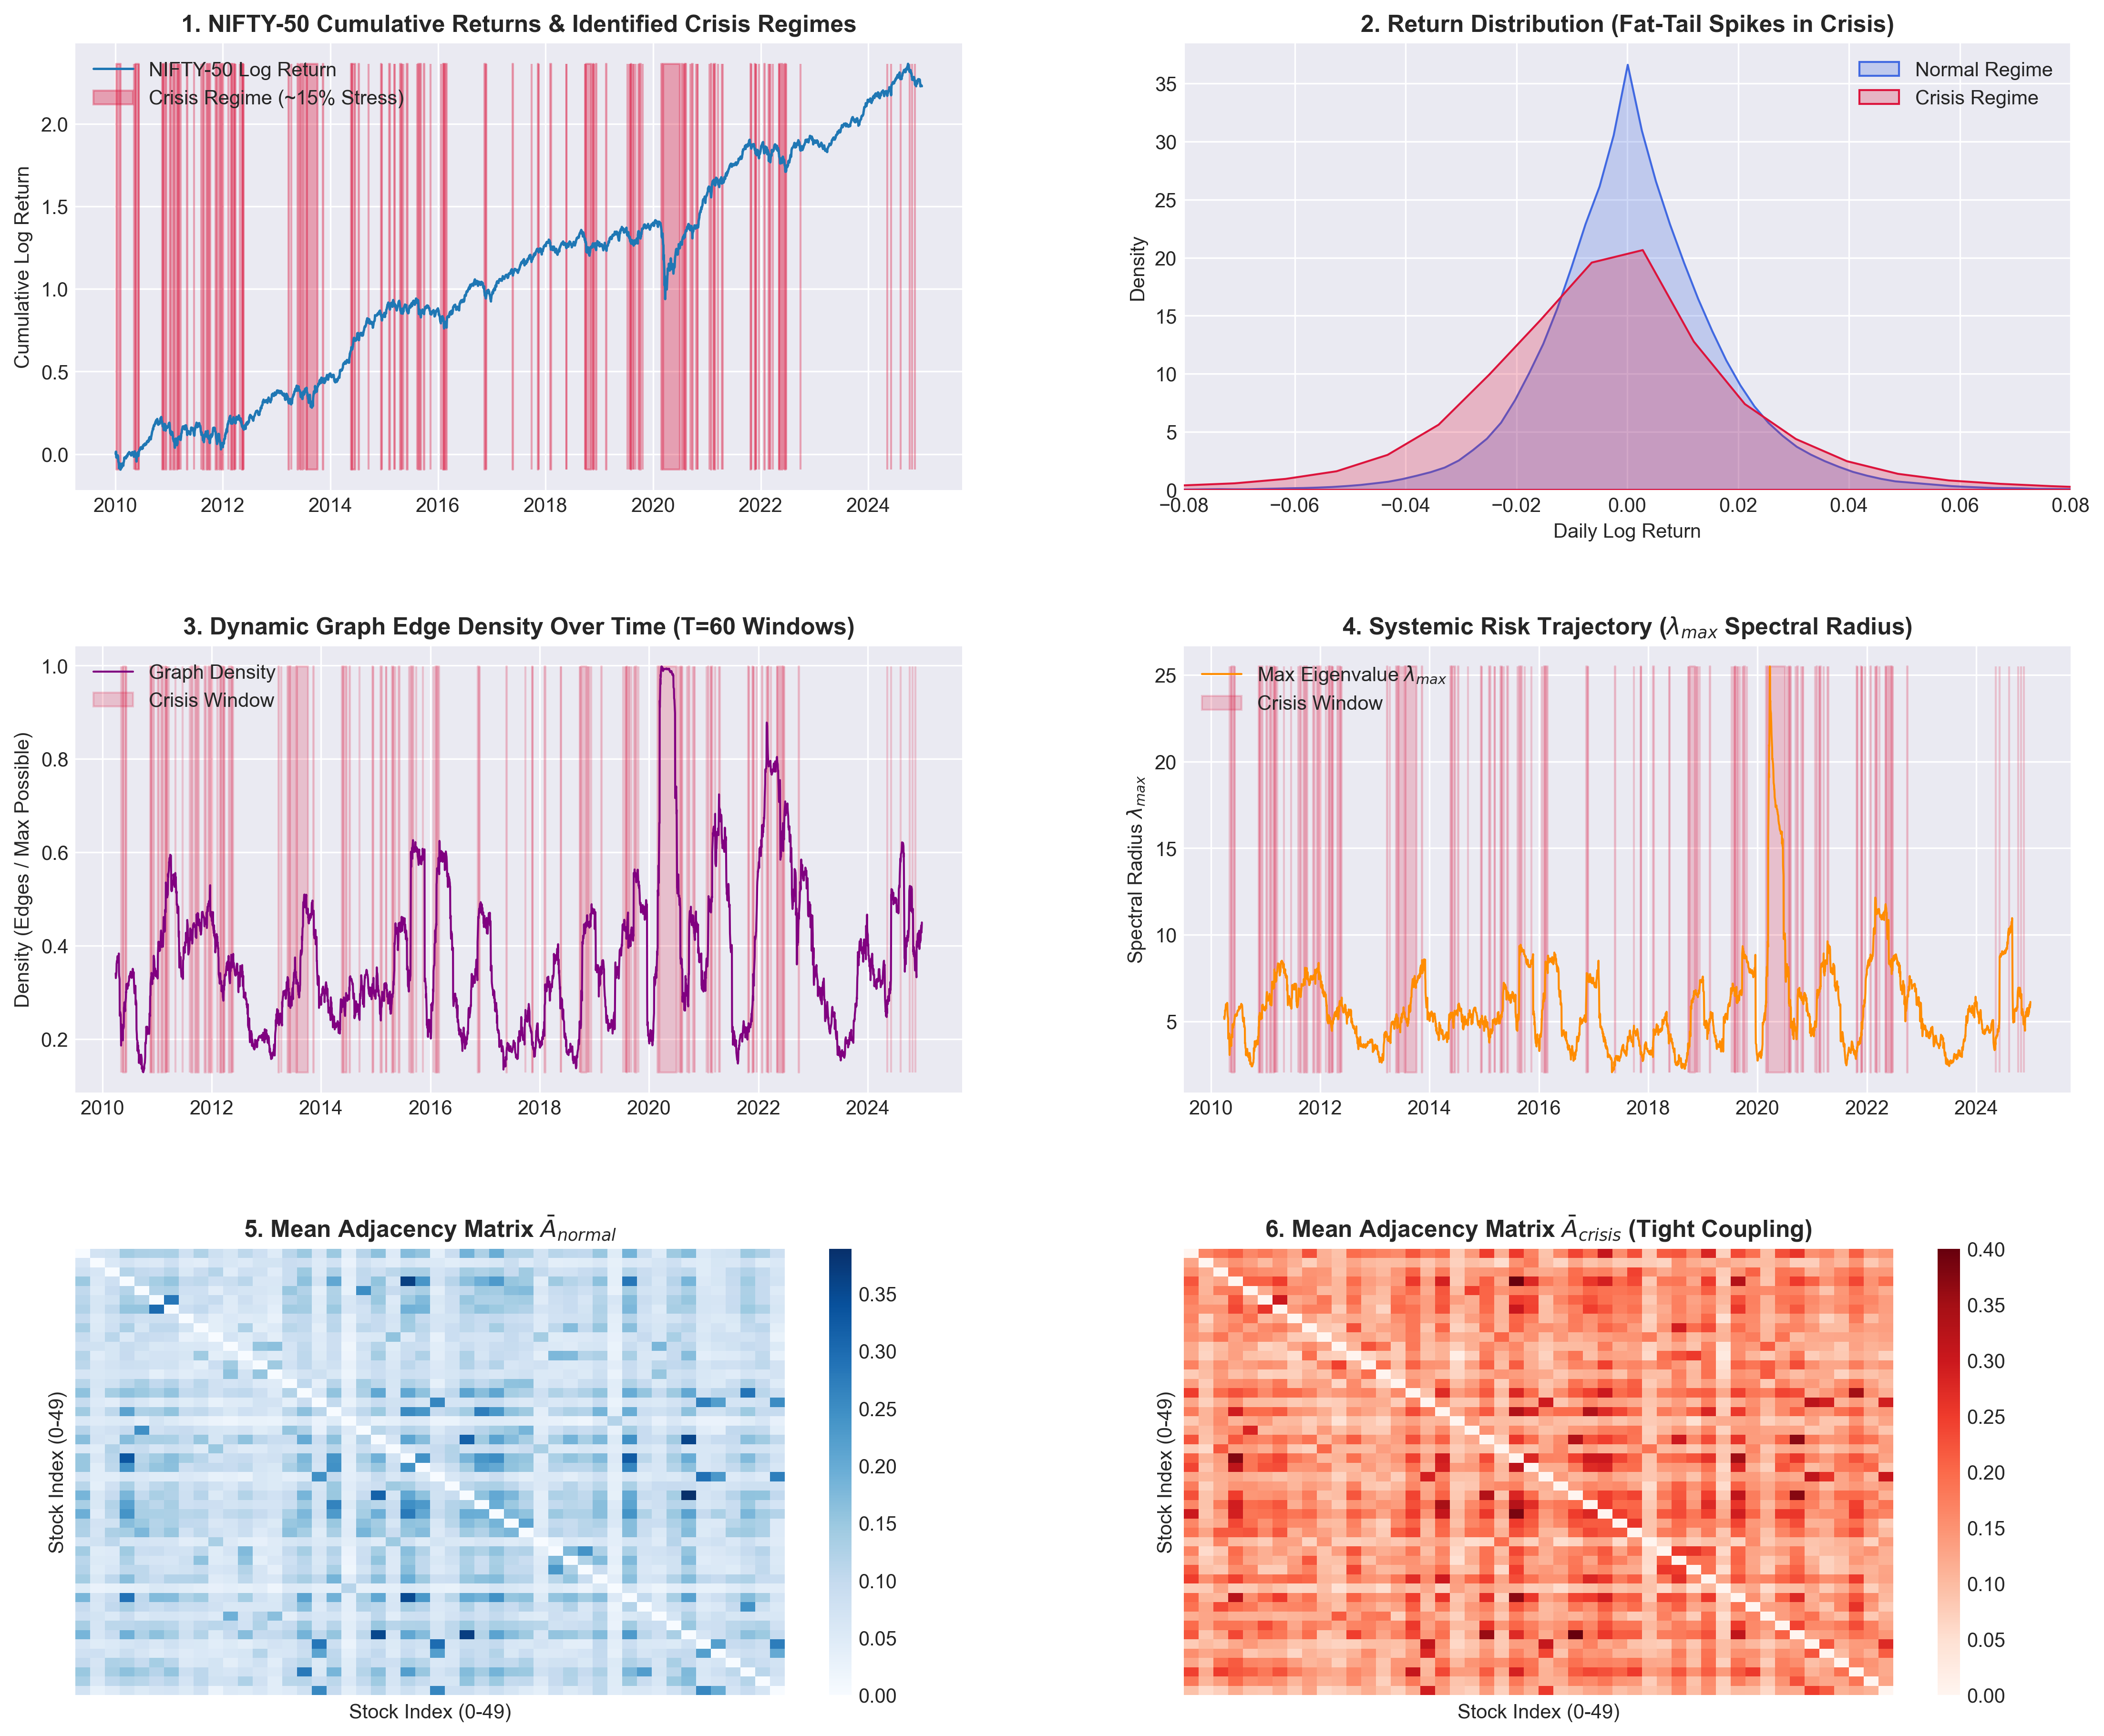

Saved Master EDA Dashboard to: \kaggle\working\data\plots\vortex_master_eda_dashboard.png


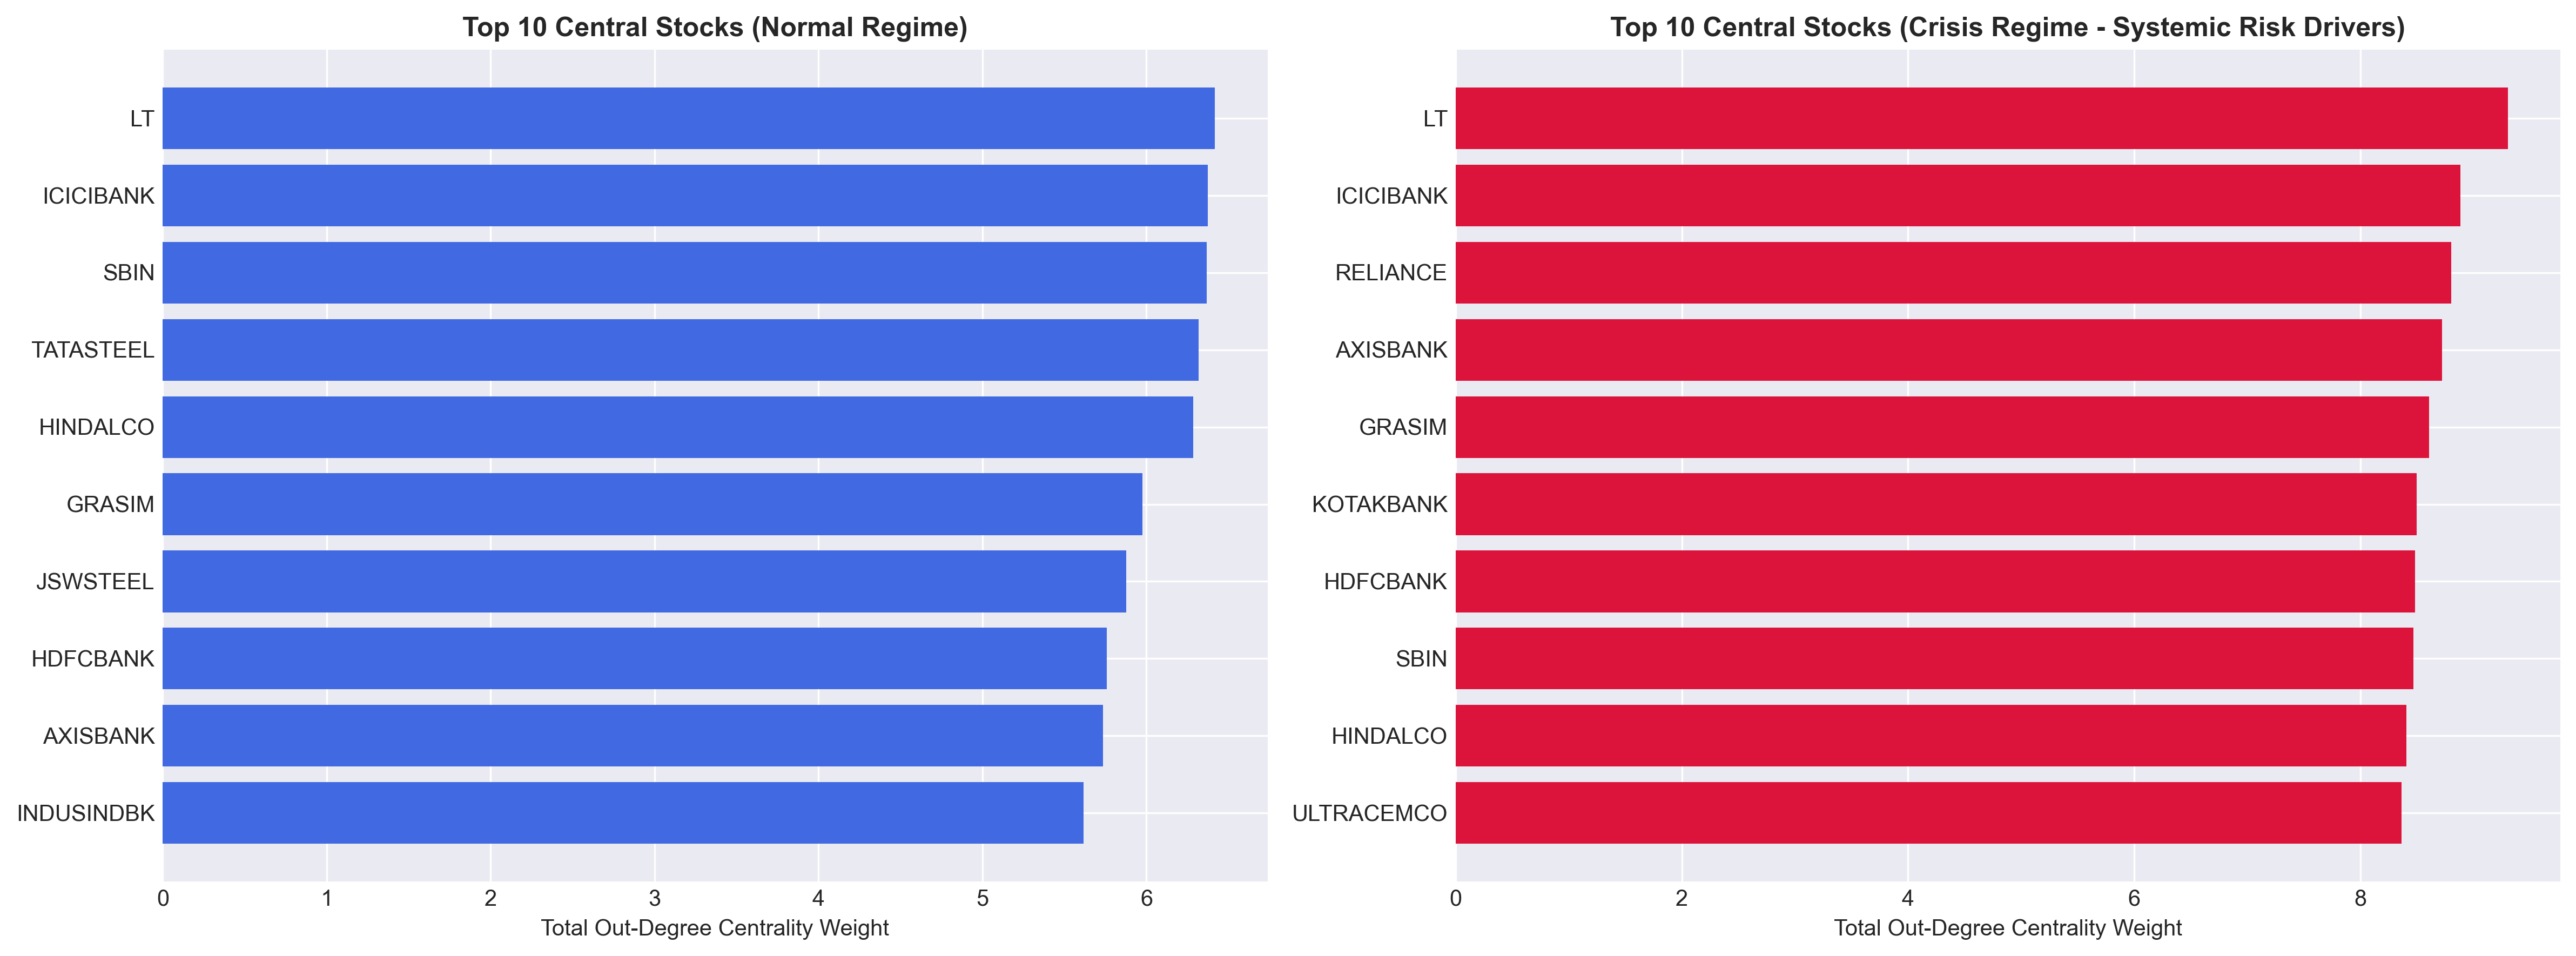

Saved Network Hub Analysis to: \kaggle\working\data\plots\vortex_network_hubs.png


In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DIR = Path(RAW_DATA_DIR)
PLOT_DIR = RAW_DIR.parent / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 10

returns = np.asarray(np.load(RAW_DIR / "returns.npy"), dtype=np.float64)
regimes = np.asarray(np.load(RAW_DIR / "regimes.npy"), dtype=np.int64).reshape(-1)
adjacency = np.asarray(np.load(RAW_DIR / "adj_matrices.npy"), dtype=np.float64)
window_regimes = np.asarray(np.load(RAW_DIR / "window_regimes.npy"), dtype=np.int64).reshape(-1)

if returns.ndim != 2 or not np.isfinite(returns).all():
    raise ValueError("returns.npy must be a finite 2D array")
if adjacency.ndim != 3 or adjacency.shape[1] != adjacency.shape[2]:
    raise ValueError("adj_matrices.npy must have shape [windows, assets, assets]")

num_windows = min(len(adjacency), len(window_regimes))
if num_windows == 0:
    raise ValueError("No graph windows are available for EDA")
adjacency, window_regimes = adjacency[:num_windows], window_regimes[:num_windows]

try:
    close_df = pd.read_csv(RAW_DIR / "nifty50_close.csv", index_col=0, parse_dates=True)
    tickers = [str(column).replace(".NS", "") for column in close_df.columns]
    dates = close_df.index[-len(returns):]
except (OSError, ValueError, KeyError):
    tickers = [f"S{i:02d}" for i in range(returns.shape[1])]
    dates = np.arange(len(returns))

if len(tickers) != returns.shape[1]:
    tickers = [f"S{i:02d}" for i in range(returns.shape[1])]
window_size = 60
window_dates = dates[window_size - 1 : window_size - 1 + num_windows]
if len(window_dates) != num_windows:
    window_dates = np.arange(num_windows)
num_assets = returns.shape[1]
max_edges = max(num_assets * (num_assets - 1), 1)

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Panel 1: cumulative return with crisis shading.
ax1 = axes[0, 0]
cumulative = np.cumsum(returns.mean(axis=1))
ax1.plot(dates, cumulative, color="#1f77b4", linewidth=1.2, label="NIFTY-50 Log Return")
ax1.fill_between(dates, cumulative.min(), cumulative.max(), where=(regimes[: len(dates)] == 1), color="crimson", alpha=0.35, label="Crisis Regime (~15% Stress)")
ax1.set_title("1. NIFTY-50 Cumulative Returns & Identified Crisis Regimes", fontweight="bold")
ax1.set_ylabel("Cumulative Log Return")
ax1.legend(loc="upper left")

# Panel 2: return density by regime (crisis shows fatter tails).
ax2 = axes[0, 1]
normal_ret = returns[regimes == 0].flatten()
crisis_ret = returns[regimes == 1].flatten()
if normal_ret.size >= 2 and np.ptp(normal_ret) > 0:
    sns.kdeplot(normal_ret, ax=ax2, color="royalblue", label="Normal Regime", fill=True, alpha=0.25)
else:
    ax2.hist(normal_ret, bins=20, color="royalblue", alpha=0.35, label="Normal Regime")
if crisis_ret.size >= 2 and np.ptp(crisis_ret) > 0:
    sns.kdeplot(crisis_ret, ax=ax2, color="crimson", label="Crisis Regime", fill=True, alpha=0.25)
else:
    ax2.hist(crisis_ret, bins=20, color="crimson", alpha=0.35, label="Crisis Regime")
ax2.set_xlim(-0.08, 0.08)
ax2.set_title("2. Return Distribution (Fat-Tail Spikes in Crisis)", fontweight="bold")
ax2.set_xlabel("Daily Log Return")
ax2.set_ylabel("Density")
ax2.legend()

# Panel 3: dynamic graph edge density over time.
ax3 = axes[1, 0]
edge_density = [np.count_nonzero(matrix) / max_edges for matrix in adjacency]
ax3.plot(window_dates, edge_density, color="purple", linewidth=1.0, label="Graph Density")
ax3.fill_between(window_dates, min(edge_density), max(edge_density), where=(window_regimes == 1), color="crimson", alpha=0.2, label="Crisis Window")
ax3.set_title("3. Dynamic Graph Edge Density Over Time (T=60 Windows)", fontweight="bold")
ax3.set_ylabel("Density (Edges / Max Possible)")
ax3.legend(loc="upper left")

# Panel 4: systemic risk via spectral radius (largest |eigenvalue| of each adjacency).
ax4 = axes[1, 1]
spectral_radius = [np.max(np.abs(np.linalg.eigvals(matrix))) for matrix in adjacency]
ax4.plot(window_dates, spectral_radius, color="darkorange", linewidth=1.0, label=r"Max Eigenvalue $\lambda_{max}$")
ax4.fill_between(window_dates, min(spectral_radius), max(spectral_radius), where=(window_regimes == 1), color="crimson", alpha=0.2, label="Crisis Window")
ax4.set_title(r"4. Systemic Risk Trajectory ($\lambda_{max}$ Spectral Radius)", fontweight="bold")
ax4.set_ylabel(r"Spectral Radius $\lambda_{max}$")
ax4.legend(loc="upper left")

# Panel 5: mean adjacency in the normal regime.
ax5 = axes[2, 0]
normal_adjacency = adjacency[window_regimes == 0]
mean_normal = normal_adjacency.mean(axis=0) if len(normal_adjacency) else np.zeros((num_assets, num_assets))
sns.heatmap(mean_normal, ax=ax5, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False)
ax5.set_title(r"5. Mean Adjacency Matrix $\bar{A}_{normal}$", fontweight="bold")
ax5.set_xlabel("Stock Index (0-49)")
ax5.set_ylabel("Stock Index (0-49)")

# Panel 6: mean adjacency in the crisis regime (tighter coupling).
ax6 = axes[2, 1]
crisis_adjacency = adjacency[window_regimes == 1]
mean_crisis = crisis_adjacency.mean(axis=0) if len(crisis_adjacency) else np.zeros((num_assets, num_assets))
sns.heatmap(mean_crisis, ax=ax6, cmap="Reds", cbar=True, xticklabels=False, yticklabels=False)
ax6.set_title(r"6. Mean Adjacency Matrix $\bar{A}_{crisis}$ (Tight Coupling)", fontweight="bold")
ax6.set_xlabel("Stock Index (0-49)")
ax6.set_ylabel("Stock Index (0-49)")

dashboard_path = PLOT_DIR / "vortex_master_eda_dashboard.png"
plt.savefig(dashboard_path, bbox_inches="tight")
plt.show()
print(f"Saved Master EDA Dashboard to: {dashboard_path}")

# Network hub analysis: top out-degree central stocks per regime.
fig_hub, (ax_hub1, ax_hub2) = plt.subplots(1, 2, figsize=(16, 6))
degree_normal = mean_normal.sum(axis=1)
degree_crisis = mean_crisis.sum(axis=1)
top_normal = np.argsort(degree_normal)[-min(10, num_assets):]
top_crisis = np.argsort(degree_crisis)[-min(10, num_assets):]

ax_hub1.barh([tickers[i] for i in top_normal], degree_normal[top_normal], color="royalblue")
ax_hub1.set_title("Top 10 Central Stocks (Normal Regime)", fontweight="bold")
ax_hub1.set_xlabel("Total Out-Degree Centrality Weight")

ax_hub2.barh([tickers[i] for i in top_crisis], degree_crisis[top_crisis], color="crimson")
ax_hub2.set_title("Top 10 Central Stocks (Crisis Regime - Systemic Risk Drivers)", fontweight="bold")
ax_hub2.set_xlabel("Total Out-Degree Centrality Weight")

plt.tight_layout()
hubs_path = PLOT_DIR / "vortex_network_hubs.png"
plt.savefig(hubs_path, bbox_inches="tight")
plt.show()
print(f"Saved Network Hub Analysis to: {hubs_path}")

## Quick Demo (merged from demo.ipynb)

A compact look at the prepared artifacts produced above: equal-weighted cumulative returns and the empirical adjacency for a representative normal vs crisis window.

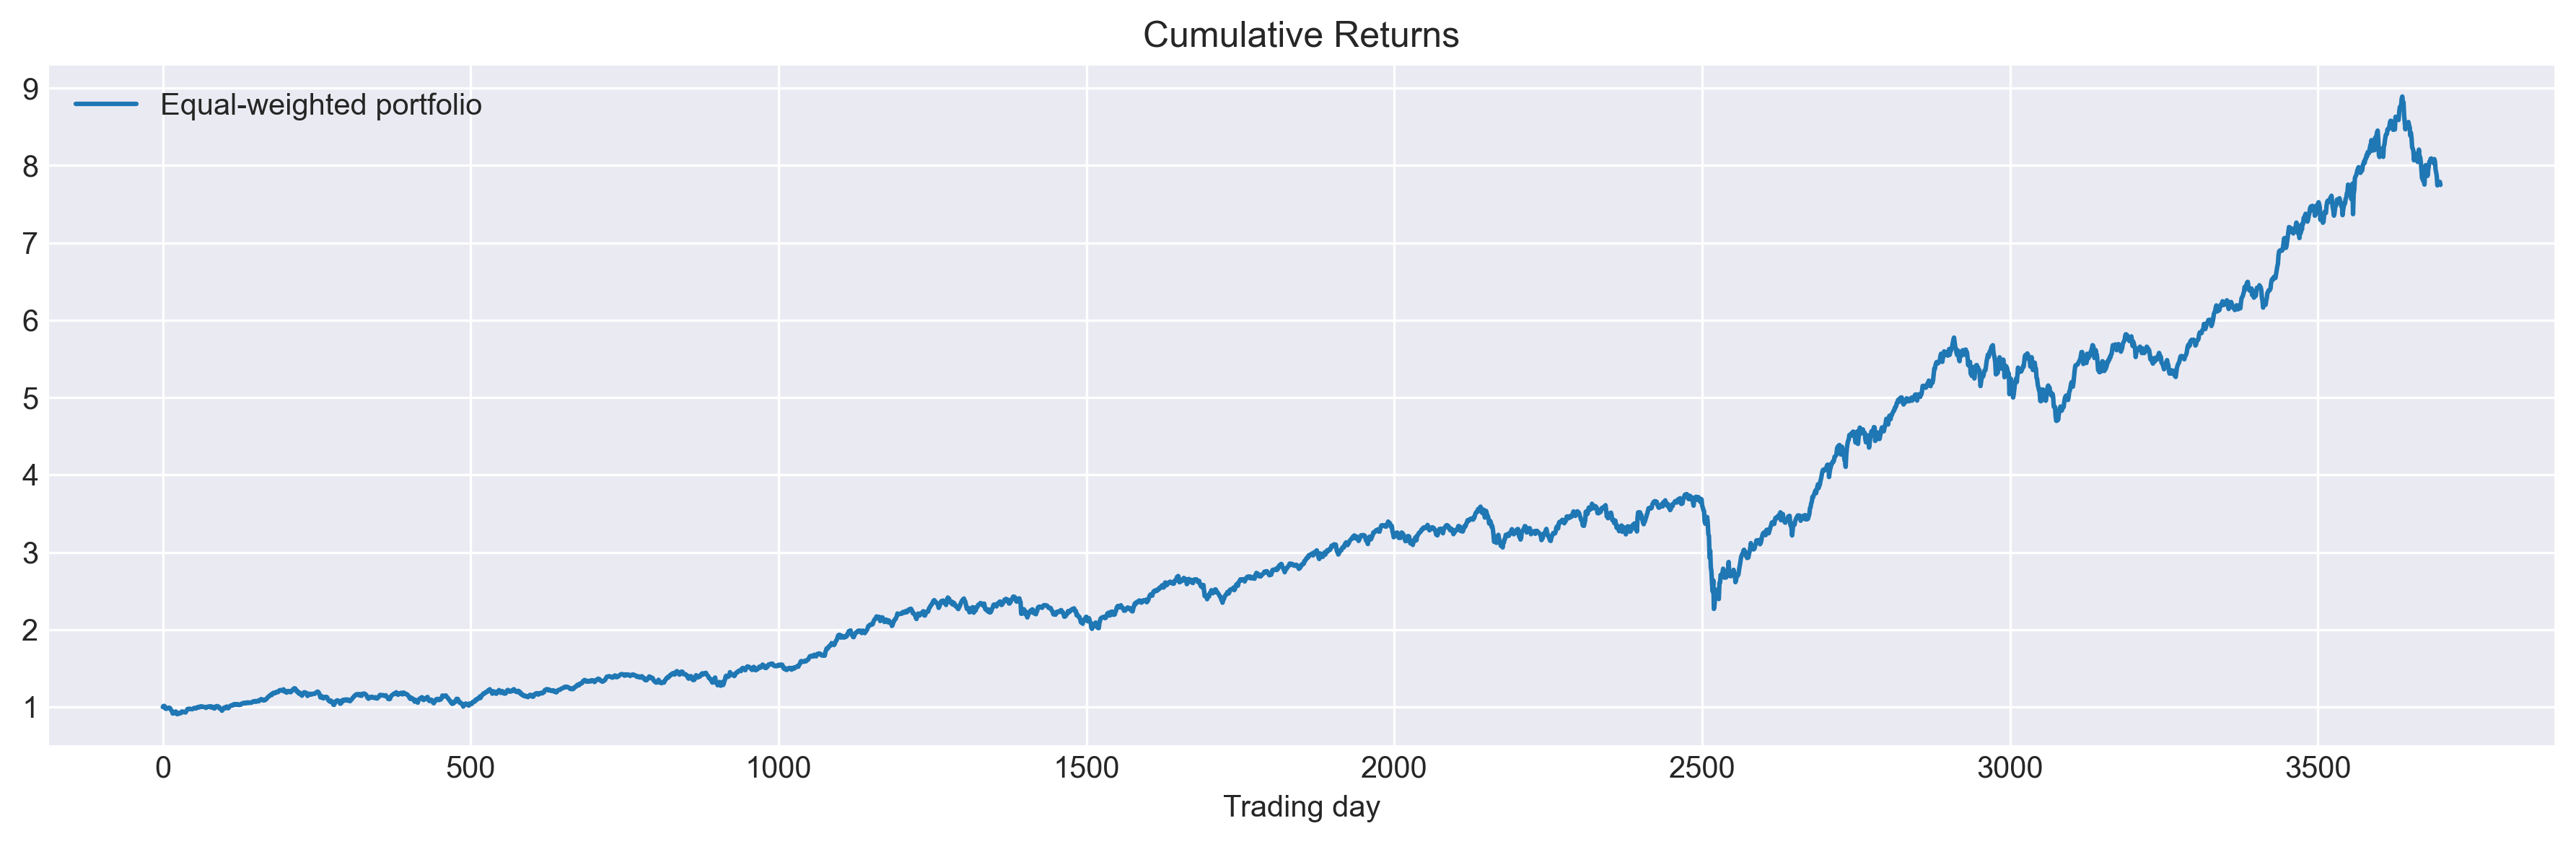

In [42]:
# Reuses returns, adjacency and window_regimes loaded in the EDA cell above.
import matplotlib.pyplot as plt

normal_indices = np.flatnonzero(window_regimes == 0)
crisis_indices = np.flatnonzero(window_regimes == 1)
if not len(normal_indices) or not len(crisis_indices):
    raise ValueError("Demo requires at least one normal and one crisis window")
normal_index = int(normal_indices[0])
crisis_index = int(crisis_indices[0])

cumulative = np.cumprod(1.0 + returns.mean(axis=1))
fig, axis = plt.subplots(figsize=(12, 4))
axis.plot(cumulative, label="Equal-weighted portfolio")
axis.set_title("Cumulative Returns")
axis.set_xlabel("Trading day")
axis.legend()
plt.tight_layout()
plt.show()

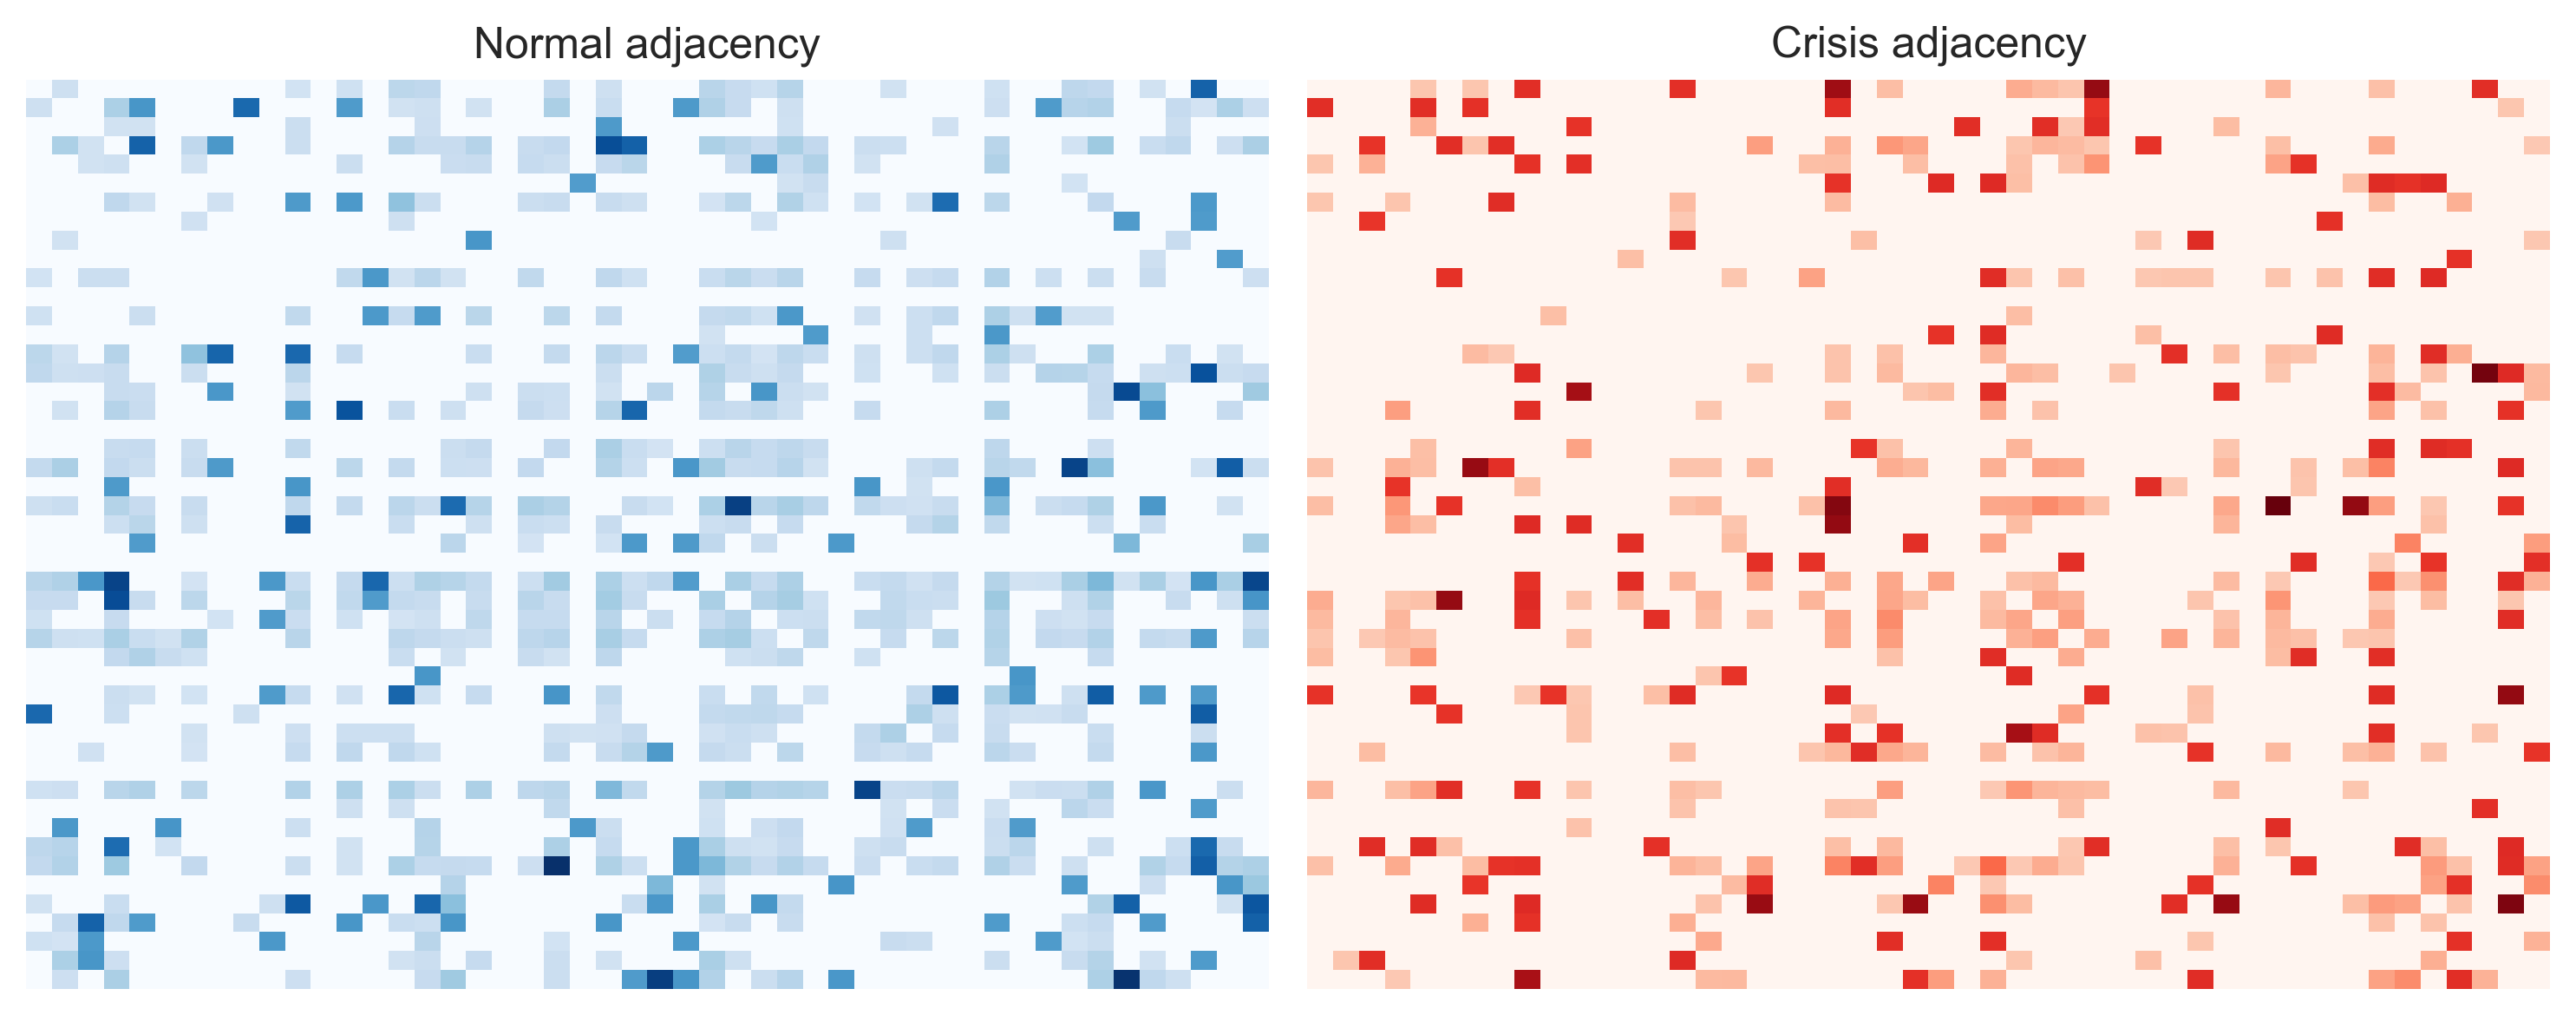

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(adjacency[normal_index], cmap="Blues", aspect="auto")
axes[0].set_title("Normal adjacency")
axes[1].imshow(adjacency[crisis_index], cmap="Reds", aspect="auto")
axes[1].set_title("Crisis adjacency")
for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
plt.tight_layout()
plt.show()

# Panel Evaluation Brief

## Problem Statement

Financial crises are not isolated stock events: correlations and lead-lag relationships can change rapidly, causing shocks to spread across sectors. Vortex-AI studies whether a dynamic graph representation of NIFTY-50 returns can identify normal versus crisis regimes and expose the assets that become systemically central.

## Research Gap

Many financial time-series studies model assets independently or use one static correlation matrix. This project combines rolling multivariate windows, empirical graph targets, graph attention, and generative baselines so that both regime classification and temporal realism can be evaluated on the same market data.

## Objectives

1. Build a reproducible 60-trading-day NIFTY-50 data pipeline.
2. Label high-stress regimes using volatility, drawdown, and circuit-proximity signals.
3. Construct dynamic Pearson and optional Granger-informed adjacency graphs.
4. Train a graph-attention classifier and compare it with spatio-temporal and generative baselines.
5. Evaluate predictive quality, graph reconstruction, and synthetic time-series fidelity.

## Proposed Architecture / Workflow

```mermaid
flowchart LR
    A[Yahoo Finance prices] --> B[Clean positive finite prices]
    B --> C[Log returns and crisis labels]
    C --> D[60-day multivariate windows]
    D --> E[Dynamic Pearson / Granger graphs]
    E --> F[GAT regime encoder]
    F --> G[Regime prediction]
    D --> H[TimeGAN baseline]
    D --> I[QuantGAN baseline]
    H --> J[Statistical and temporal evaluation]
    I --> J
    G --> K[Panel comparison]
    J --> K
```

## Implementation Evidence

The current implementation includes the end-to-end data pipeline, graph construction, GAT training, EDA dashboard, Quick Demo, TimeGAN smoke/full runners, QuantGAN preparation, and dedicated statistical/temporal evaluation modules. The notebook's final evidence cell indexes the corresponding repository files and reports the available run status.

In [44]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = next((parent for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (parent / "baselines").exists()), NOTEBOOK_DIR)
BASELINES_DIR = PROJECT_ROOT / "baselines"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

artifact_specs = {
    "Core returns": RAW_DIR / "returns.npy",
    "Core regimes": RAW_DIR / "regimes.npy",
    "Core windows": RAW_DIR / "windows.npy",
    "Core graphs": RAW_DIR / "adj_matrices.npy",
    "TimeGAN windows": BASELINES_DIR / "data" / "timegan_windows.npy",
    "QuantGAN market windows": BASELINES_DIR / "data" / "quantgan_market_windows.npy",
    "Baseline comparison": BASELINES_DIR / "baseline_comparison.csv",
    "Baseline runbook": BASELINES_DIR / "BASELINE_RUNBOOK.md",
    "TimeGAN statistical evaluation": PROJECT_ROOT / "eval" / "statistical_timegan.py",
    "TimeGAN temporal evaluation": PROJECT_ROOT / "eval" / "timegan_temporal.py",
}

inventory = pd.DataFrame([
    {"artifact": name, "status": "Available" if path.exists() else "Missing", "path": str(path.relative_to(PROJECT_ROOT))}
    for name, path in artifact_specs.items()
])
display(inventory)

comparison_path = BASELINES_DIR / "baseline_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    display(Markdown("### Baseline comparison table"))
    display(comparison)

metadata_path = BASELINES_DIR / "data" / "baseline_data_metadata.json"
if metadata_path.exists():
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    display(Markdown(
        f"**Common baseline protocol:** {metadata.get('timegan_windows_shape', 'n/a')} TimeGAN windows, "
        f"market series length {metadata.get('quantgan_market_returns_shape', 'n/a')}, "
        f"window={metadata.get('window', 'n/a')}."
    ))

result_files = [
    BASELINES_DIR / "results" / "timegan_smoke" / "stats.json",
    BASELINES_DIR / "results" / "timegan_full" / "statistics.json",
]
for result_path in result_files:
    if result_path.exists():
        result = json.loads(result_path.read_text(encoding="utf-8"))
        display(Markdown(f"**{result_path.parent.name}:** {result.get('generated_shape', 'shape unavailable')}, "
                         f"finite outputs={result.get('losses_finite', 'reported in statistics file')}"))

,artifact,status,path
0,Core returns,Available,data\raw\returns.npy
1,Core regimes,Available,data\raw\regimes.npy
2,Core windows,Available,data\raw\windows.npy
3,Core graphs,Available,data\raw\adj_matrices.npy
4,TimeGAN windows,Available,baselines\data\timegan_windows.npy
5,QuantGAN market windows,Available,baselines\data\quantgan_market_windows.npy
6,Baseline comparison,Available,baselines\baseline_comparison.csv
7,Baseline runbook,Available,baselines\BASELINE_RUNBOOK.md
8,TimeGAN statistical evaluation,Available,eval\statistical_timegan.py
9,TimeGAN temporal evaluation,Available,eval\timegan_temporal.py


### Baseline comparison table

,model_name,dataset_name,window,epochs,batch_size,learning_rate,train_time_min,generated_samples,mse_mean,acf_lag1_real,acf_lag1_synth,notes
0,TimeGAN,NIFTY50_multivariate,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QuantGAN,NIFTY50_market_return,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CG-NSDE,NIFTY50_multivariate,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Common baseline protocol:** [3640, 60, 50] TimeGAN windows, market series length [3700], window=60.

**timegan_smoke:** (15360, 50), finite outputs=reported in statistics file

**timegan_full:** [3640, 60, 50], finite outputs=True

## Evaluation Mapping

| Rubric area | Evidence in this notebook / repository |
| --- | --- |
| Problem clarity and SDG mapping (CO1) | Financial contagion problem, measurable objectives, and SDG 8 / SDG 9 / SDG 16 relevance through resilient finance, responsible innovation, and transparent risk analysis. |
| Literature survey and research gap (CO2) | The gap between independent/static asset modelling and dynamic graph plus generative evaluation is stated above; supporting implementation references are indexed in the evidence cell. |
| Theory and 20% implementation (CO3) | Log-return mathematics, crisis scoring, Pearson/Granger graph construction, GAT attention, chronological validation, TimeGAN, QuantGAN, and statistical/temporal metrics. |
| Presentation (CO5) | EDA dashboard, regime shading, graph-density and spectral-risk plots, hub analysis, adjacency comparison, and this structured brief. |
| Teamwork and professional ethics (CO5/CO6) | Reproducible configs, runbook, cached artifacts, explicit smoke/full status, finite-loss checks, and separation of completed results from pending baseline metrics. |

## Current Status for Phase 1

**Implemented:** core data preparation, dynamic graph generation, GAT training, EDA visualizations, Quick Demo, TimeGAN smoke/full workflow, and evaluation modules.

**Evidence available:** aligned core artifacts, baseline data metadata, TimeGAN smoke statistics, completed TimeGAN full statistics, configuration files, runbook, and comparison-table scaffold.

**Next milestone:** complete and record QuantGAN training metrics, run the final cross-model comparison, and report limitations such as survivorship bias, data availability, regime-label sensitivity, and the distinction between correlation and causation.

## SDG Relevance

- **SDG 8: Decent Work and Economic Growth:** earlier detection of systemic financial stress supports more resilient economic activity.
- **SDG 9: Industry, Innovation and Infrastructure:** develops an explainable graph-based research prototype for financial infrastructure.
- **SDG 16: Peace, Justice and Strong Institutions:** reproducible evaluation and transparent risk indicators support accountable decision-making.

> **Presentation note:** The notebook demonstrates approximately the Phase 1 implementation slice. It is a research prototype, not a trading recommendation or a claim of causal financial prediction.